In [1]:
## Sample code to plot structure function from CJ15 LHAPDF data sets
## Shujie Li, Feb, 2022
## Ref: DOI: 10.1103/PhysRevD.93.114017

import numpy as np
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
import collections
import pandas as pd
# from numpy import linalg as LA
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.colors as colors
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "16"
plt.rcParams["figure.figsize"] = (10,6)
mpl.rcParams['lines.linewidth'] = 1

import lhapdf
# lhapdf.pathsPrepend("Your path to CJ LHAPDF sets")



# Definitions
* CJ15 provides 49 PDF sets. set 0 for central value. The other 48 = 2*24 give T=1.645 error band in 24 eigen-directions. CJ style symmetric uncertainty:
\begin{equation}
\delta^{CJ} \lambda
= \frac{1}{2}
  \sqrt{\sum_{j=1}^{24}
    \Big[ \lambda^{(2j-1)} - \lambda^{(2j)} \Big]^2} \ 
\end{equation}


* See structure function index conventions at 
https://jeffersonlab.github.io/txgrids/_build/html/grids.html#structure-function-index-convention

In [2]:
def calc_sfn(x,Q2,tabname,iset=908,kerr=0):
    err = np.zeros(len(x))
#     if kerr == 0: 
    set0     = lhapdf.mkPDF(tabname,0)
    sfn      = np.array(set0.xfxQ2(iset,x,Q2))
    if kerr==1:
        sets=lhapdf.mkPDFs(tabname)
        if len(sets)==1:
            return sfn, err
        ## CJ style error calculation, see 
        if "CJ" in tabname.upper():
            for ii in np.arange(0,24):
#             set1    = lhapdf.mkPDF(tabname,int(2*ii+1))
#             set2    = lhapdf.mkPDF(tabname,int(2*ii+2))
                sfn1    = np.array(sets[2*ii+1].xfxQ2(iset,x,Q2))
                sfn2    = np.array(sets[2*ii+2].xfxQ2(iset,x,Q2))
                err += (sfn1-sfn2)**2
            err = np.sqrt(err)/2.0
            
        else:
        ## for all other sets, take mean and sigma
            n = len(sets)
            sfn = []
            for ii in np.arange(0,n):
                sfn.append(np.array(sets[ii].xfxQ2(iset,x,Q2)))
            sfn = np.array(sfn)
            err = sfn.std(axis=0)
            sfn = sfn.mean(axis=0)
    return sfn, err

def calc_sfn_np(x,Q2,tabp = "CJ15-FpNC", tabn = "CJ15-FnNC", iset=908,kerr=0,p_n=0):
#     tabp = "CJ15-FpNC"
#     tabn = "CJ15-FnNC"
    err = np.zeros(len(x))
    if kerr==0:
        setp0      = lhapdf.mkPDF(tabp,0)
        setn0      = lhapdf.mkPDF(tabn,0)
        if p_n:
            sfn0       = np.array(setp0.xfxQ2(iset,x,Q2))-np.array(setn0.xfxQ2(iset,x,Q2))

        else:
            sfn0       = np.array(setn0.xfxQ2(iset,x,Q2))/np.array(setp0.xfxQ2(iset,x,Q2))
        
    else:
        setp=lhapdf.mkPDFs(tabp)
        setn=lhapdf.mkPDFs(tabn)

        if p_n:
            sfn0  = np.array(setp[0].xfxQ2(iset,x,Q2))-np.array(setn[0].xfxQ2(iset,x,Q2))
        else:
            sfn0  = np.array(setn[0].xfxQ2(iset,x,Q2))/np.array(setp[0].xfxQ2(iset,x,Q2))
        if len(setp)==1:
            return sfn0, err

        for ii in np.arange(0,24):
            setp1    = setp[2*ii+1]
            setp2    = setp[2*ii+2]
            setn1    = setn[2*ii+1]
            setn2    = setn[2*ii+2]
            if p_n:
                sfn1    = np.array(setp1.xfxQ2(iset,x,Q2))-np.array(setn1.xfxQ2(iset,x,Q2))
                sfn2    = np.array(setp2.xfxQ2(iset,x,Q2))-np.array(setn2.xfxQ2(iset,x,Q2))
               
            else:
                sfn1    = np.array(setn1.xfxQ2(iset,x,Q2))/np.array(setp1.xfxQ2(iset,x,Q2))
                sfn2    = np.array(setn2.xfxQ2(iset,x,Q2))/np.array(setp2.xfxQ2(iset,x,Q2))
            
            err += (sfn1-sfn2)**2
        err = np.sqrt(err)/2.0
    return sfn0, err

# Plot F2p NC and CC

LHAPDF 6.3.0 loading /Users/shujie/jlab/CJ/CJgrids/downloads/GRIDS-LHA/CJ15-FpNC/CJ15-FpNC_0000.dat
CJ15-FpNC PDF set, member #0, version 1
LHAPDF 6.3.0 loading /Users/shujie/jlab/CJ/CJ-code/fitpack/PDFerr/CJ15-FpCC/CJ15-FpCC_0000.dat
CJ15-FpCC PDF set, member #0, version 1
LHAPDF 6.3.0 loading /Users/shujie/jlab/txgrids/stf-grids/NNPDF31_nnlo_pch_as_0118_SF/NNPDF31_nnlo_pch_as_0118_SF_0000.dat
NNPDF31_nnlo_pch_as_0118_SF PDF set, member #0, version 1
LHAPDF 6.3.0 loading all 101 PDFs in set NNPDF31_nnlo_pch_as_0118_SF
NNPDF31_nnlo_pch_as_0118_SF, version 1; 101 PDF members
LHAPDF 6.3.0 loading /Users/shujie/jlab/CJ/CJ-code/fitpack/PDFerr/CJ15-FpCC/CJ15-FpCC_0000.dat
CJ15-FpCC PDF set, member #0, version 1
LHAPDF 6.3.0 loading /Users/shujie/jlab/txgrids/stf-grids/NNPDF31_nnlo_pch_as_0118_SF/NNPDF31_nnlo_pch_as_0118_SF_0000.dat
NNPDF31_nnlo_pch_as_0118_SF PDF set, member #0, version 1
LHAPDF 6.3.0 loading all 101 PDFs in set NNPDF31_nnlo_pch_as_0118_SF
NNPDF31_nnlo_pch_as_0118_SF, versi

(0.0, 0.9)

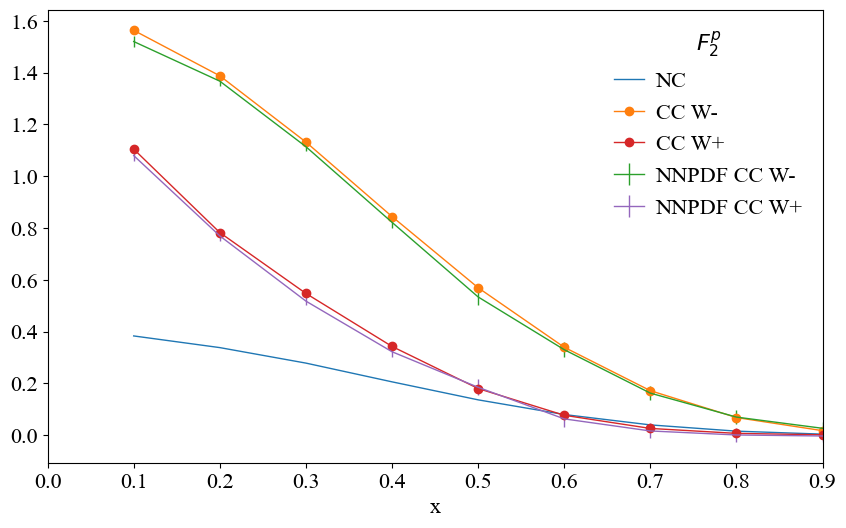

In [3]:
x = np.arange(0,1,0.1)
Q2 = np.ones(len(x))*10

plt.figure(dpi=100)

## F2NC
iset = 908 #
f2p=calc_sfn(x,Q2,"CJ15-FpNC",iset,0)
plt.plot(x,f2p[0],label="NC")

## F2CC W-
iset = 930
f2cp=calc_sfn(x,Q2,"CJ15-FpCC",iset,0)
plt.plot(x,f2cp[0],'o-',label="CC W-")
f2cp=calc_sfn(x,Q2,"NNPDF31_nnlo_pch_as_0118_SF",iset,1)
plt.errorbar(x,f2cp[0],yerr=f2cp[1],label="NNPDF CC W-")

# f2cp=calc_sfn(x,Q2,"JAM4EIC_p",iset,1)
# plt.errorbar(x,f2cp[0],yerr=f2cp[1],label="JAM4EIC CC W-")

## F2CC W+
iset = 940
f2cp=calc_sfn(x,Q2,"CJ15-FpCC",iset,0)
plt.plot(x,f2cp[0],'o-',label="CC W+")
f2cp=calc_sfn(x,Q2,"NNPDF31_nnlo_pch_as_0118_SF",iset,1)
plt.errorbar(x,f2cp[0],yerr=f2cp[1],label="NNPDF CC W+")
# f2cp=calc_sfn(x,Q2,"JAM4EIC_p",iset,1)
# plt.errorbar(x,f2cp[0],yerr=f2cp[1],label="JAM4EIC CC W+")

plt.legend(title=r"$F_2^p$",loc="upper right",fontsize=16,frameon=False,handlelength=1.35,handletextpad=0.5)

plt.xlabel("x")
plt.xlim(0,0.9)

